In [45]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

In [42]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

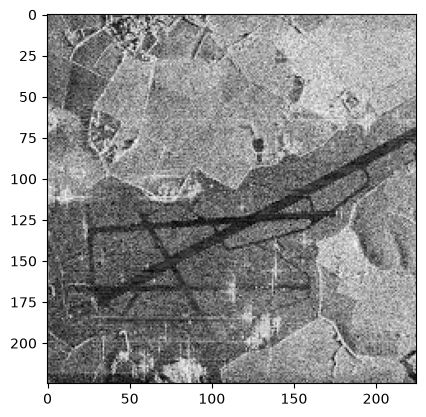

In [43]:
plt.imshow(image_gray, cmap="gray")

# 1

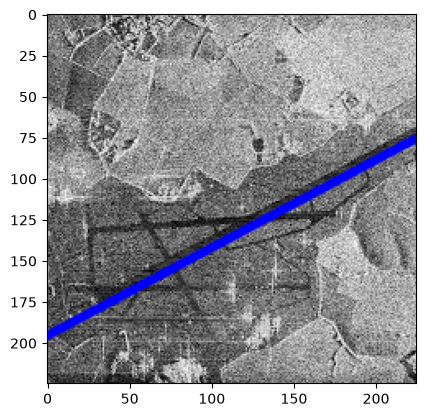

In [46]:
canny = cv2.Canny(image_gray, 130, 400, apertureSize=3)

lines = cv2.HoughLines(canny, 1, np.pi / 180, 120)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image, pt1, pt2, (0, 0 , 255), 3, cv2.LINE_AA)

plt.imshow(image)

# 2

# Отсу бинаризация

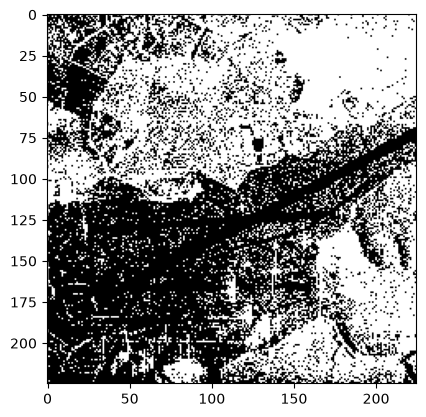

In [ ]:

_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

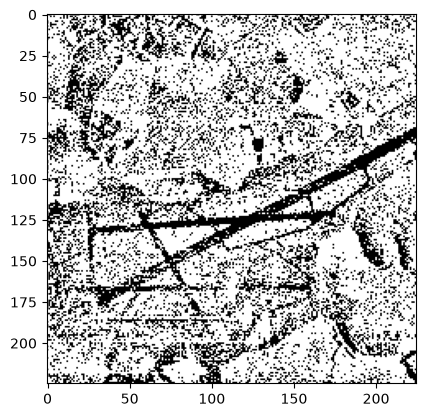

In [39]:

th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)
plt.imshow(th3, cmap="gray")

# Точечная Бинаризация

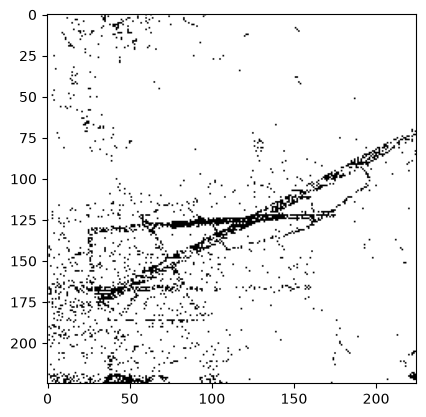

In [40]:
import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.imshow(bin_img, cmap="gray")